# Kepler Analysis - Key Insight and Proof-Of-Concept

This notebook presents a **proof-of-concept** for Keplerian analysis by estimating **Mars'** position using Earth-based **line-of-sight (LOS) measurements**. It is part of a series that demonstrates how **observational data** can be harnessed to determine planetary orbits.

**Contact:** Luca.Canali@cern.ch  
**Date:** February 2025

---
### Key Insight
Mars completes one full revolution around the Sun in **687 days** (one Mars year). During this period, **Earth occupies a different position** in its orbit at each observation. By selecting measurements taken exactly **one Mars year apart**, we capture Mars' apparent position from varied vantage points. With enough observations over several Mars years, these multiple perspectives enable us to **triangulate the position of Mars**.

## Overview

In this notebook, we reconstruct Mars' orbit using a **least-squares triangulation method** based on Earth-based observations:

- **Data Ingestion & Preparation**
  - Load the dataset (`line_of_sight_mars_from_earth.csv`) with Mars and Sun observations, notably the following fields: Date, Mars Ecliptic Longitude (deg), and Sun Ecliptic Longitude (deg).

- **Triangulating Mars' Position**  
  - Select observations spaced **687 days apart** (one Mars year) so that Mars is observed at nearly the same position relative to the Sun for each measurement.
  - For each observation, compute Earth's position in the ecliptic and derive Mars' **line-of-sight vectors**.
  - Apply **least-squares estimation** to solve for Mars' **ecliptic coordinates**.

- **Visualization**  
  - Demonstrate how these LOS measurements converge to reveal Mars' estimated position.
  - Mark Earth's positions at the selected timestamps and overlay the corresponding **line-of-sight vectors**.
  - Plot the **Sun** at the origin and depict **Earth’s orbit** as a unit circle (1 AU).


## Triangulate line-of-sight vectors to find Mars position

In [1]:
import pandas as pd
import numpy as np

# -------------------------------
# 1. Read CSV data from ephemeris file
# -------------------------------
folder = "../Data/"
csv_filename = "ephemeris_mars_sun.csv"

df = pd.read_csv(folder + csv_filename)
df["Date"] = pd.to_datetime(df["Date"])

# -------------------------------
# 2. Select measurements starting at start_date,
#    then at intervals of ~1 Mars year (687 days)
# -------------------------------
start_date = pd.to_datetime("2000-01-01")
n_measurements = 6  # Configurable: number of measurements to use
interval = pd.Timedelta(days=687)  # Approximate Mars year in days

selected_rows = []
i = 0  # Counter for intervals

# Continue looping until we have n_measurements rows
while len(selected_rows) < n_measurements:
    target_date = start_date + i * interval
    # Check if an exact measurement for target_date exists in the DataFrame.
    if target_date in df["Date"].values:
        row = df[df["Date"] == target_date].iloc[0]
        selected_rows.append(row)
    i += 1

print("Selected measurement dates:")
for row in selected_rows:
    print(row["Date"].date())

# -------------------------------
# 3. Estimate Mars' heliocentric position using least squares.
#
#    For each observation:
#    - Approximate Earth's heliocentric ecliptic longitude as:
#           Earth_lon = (Sun_ecliptic_lon + 180) mod 360
#      and set Earth's position (E) as [cos(Earth_lon), sin(Earth_lon)] assuming 1 AU.
#
#    - Compute Mars's LOS unit vector from its geocentric ecliptic longitude:
#           v = [cos(Mars_eclip_lon), sin(Mars_eclip_lon)]
#
#    Then for each observation, form the projection matrix A_i = I - v v^T and accumulate:
#
#         A_total * M = Σ(A_i * E)
#
#    Finally, solve for M (Mars' heliocentric position in AU).
# -------------------------------
I = np.eye(2)
A_total = np.zeros((2, 2))
b_total = np.zeros(2)

# Conversion factor from degrees to radians
deg_to_rad = np.pi / 180.0

earth_positions = []
mars_los_vectors = []

for row in selected_rows:
    # Compute Earth's heliocentric ecliptic longitude from Sun's apparent longitude
    sun_eclip_lon_deg = row["Sun Ecliptic Longitude (deg)"]
    earth_eclip_lon_deg = (sun_eclip_lon_deg + 180) % 360
    earth_eclip_lon_rad = earth_eclip_lon_deg * deg_to_rad
    
    # Earth's position in the ecliptic plane (assuming 1 AU)
    E = np.array([np.cos(earth_eclip_lon_rad), np.sin(earth_eclip_lon_rad)])
    
    # Compute Mars geocentric LOS vector using Mars ecliptic longitude
    mars_eclip_lon_deg = row["Mars Ecliptic Longitude (deg)"]
    mars_eclip_lon_rad = mars_eclip_lon_deg * deg_to_rad
    v = np.array([np.cos(mars_eclip_lon_rad), np.sin(mars_eclip_lon_rad)])
    
    earth_positions.append(E)
    mars_los_vectors.append(v)
    
    # Compute the projection matrix A_i = I - v v^T
    A_i = I - np.outer(v, v)
    A_total += A_i
    b_total += A_i @ E

# Solve the least squares problem for Mars' heliocentric position M_est
M_est = np.linalg.solve(A_total, b_total)
print("\nEstimated Mars position (AU):", M_est)


Selected measurement dates:
2000-01-01
2001-11-18
2003-10-06
2005-08-23
2007-07-11
2009-05-28

Estimated Mars position (AU): [ 1.3870871  -0.00869006]


## Visualization of the triangulation of Mars

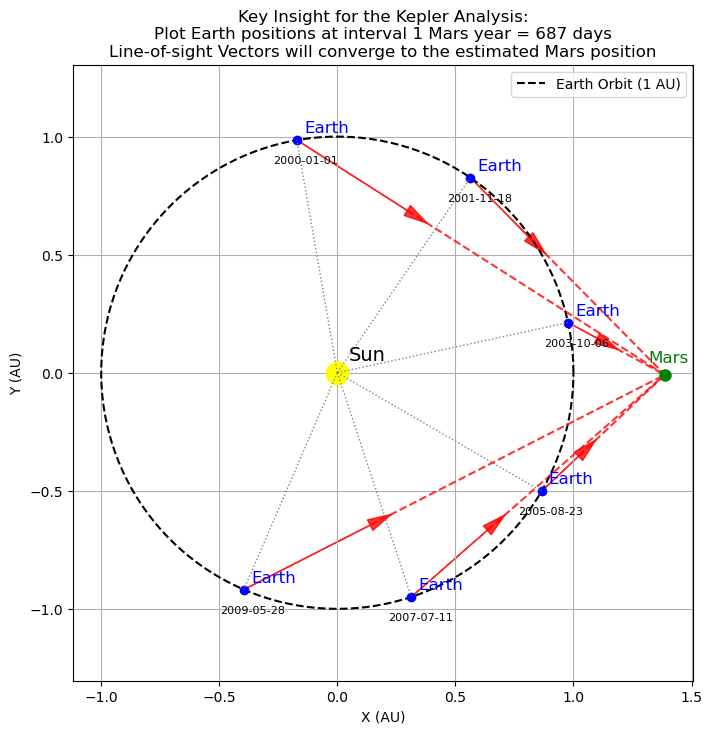

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8))

# Plot the Sun at the origin
plt.plot(0, 0, marker='o', color='yellow', markersize=16)
plt.text(0.05, 0.05, 'Sun', fontsize=14, color='black')

# Plot Earth's orbit (unit circle)
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta), 'k--', label='Earth Orbit (1 AU)')

# For each selected measurement, plot Earth's position and LOS vector.
# We'll draw a short solid arrow from Earth, then a dashed line continuing to Mars.
arrow_fraction = 0.3  # fraction of the total distance for the solid arrow

for row, E, v in zip(selected_rows, earth_positions, mars_los_vectors):
    # Plot Earth position as a blue circle with a label.
    plt.plot(E[0], E[1], 'bo')
    plt.text(E[0] + 0.03, E[1] + 0.03, 'Earth', fontsize=12, color='blue')
    
    # Draw a grey dotted line from Earth to the Sun.
    plt.plot([0, E[0]], [0, E[1]], color='grey', linestyle=':', linewidth=1)
    
    # Compute the full vector from Earth to estimated Mars.
    delta = M_est - E
    
    # Determine the tip of the solid arrow (a fraction of the full distance).
    arrow_tip = E + arrow_fraction * delta
    
    # Draw the solid arrow from Earth to arrow_tip.
    plt.arrow(E[0], E[1],
              arrow_tip[0] - E[0],
              arrow_tip[1] - E[1],
              head_width=0.05, head_length=0.1, fc='r', ec='r', alpha=0.8)
    
    # Draw the dashed line from the arrow tip to the estimated Mars position.
    plt.plot([arrow_tip[0], M_est[0]],
             [arrow_tip[1], M_est[1]], 'r--', alpha=0.8)
    
    # Optionally, annotate the measurement date.
    plt.text(E[0] - 0.1, E[1] - 0.1, row["Date"].strftime("%Y-%m-%d"),
             fontsize=8, color='black')

# Plot estimated Mars position as a green circle (round marker) and label it.
plt.plot(M_est[0], M_est[1], 'go', markersize=8)
plt.text(M_est[0] - 0.07, M_est[1] + 0.05, 'Mars', fontsize=12, color='green')

plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.title("Key Insight for the Kepler Analysis:\nPlot Earth positions at interval 1 Mars year = 687 days\nLine-of-sight Vectors will converge to the estimated Mars position")
plt.legend(loc="upper right")
plt.axis("equal")
plt.grid(True)
plt.show()
